# Interactive Linguistic Analysis of Online News Texts

> **Author:** *Aleksandra Panek*
> 
> **Course:** Academic Writing
> 
> **Date:** June 2026

---

## Abstract

Language leaves measurable patterns. In this project, I combine **web scraping**, **natural language processing (NLP)**, and **data visualization** to investigate the linguistic characteristics of an online news page, specifically the [BBC](https://www.bbc.com/) page. Using **Beautiful Soup**, I collect textual data directly from the website, while **NLTK** is used to perform several fundamental linguistic analyses, including tokenization, frequency analysis, lexical diversity measurement, and part-of-speech tagging.

The aim of this notebook is not only to demonstrate technical skills in Python, but also to explore how computational methods can reveal patterns that are difficult to notice through manual reading alone.

---

## 1. Introduction

Traditional linguistic analysis often relies on close reading. While this approach provides depth, it can be difficult to apply to large amounts of text. Computational linguistics offers a complementary perspective by allowing researchers to process and analyze language automatically.

In this notebook, I address the following questions:

1. What are the most frequent words in an online news homepage?
2. How lexically diverse is the text?
3. Which grammatical categories dominate the page?
4. What can these statistics tell us about the style of the text?

---


## 2. Importing Libraries

---

In [1]:
import requests
from bs4 import BeautifulSoup

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag, FreqDist

import pandas as pd
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\olcia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\olcia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\olcia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\olcia\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\olcia\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True


## 3. Collecting Data from the Web

For this demonstration, I use the BBC page. News articles are particularly interesting because they combine informative language with stylistic choices intended to engage readers.

---

In [2]:
url = "https://www.bbc.com/"

response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

paragraphs = soup.find_all("p")

text = " ".join([p.get_text() for p in paragraphs])

print(text[:1001])

A public spending watchdog examines the property arrangements of royals including Andrew Mountbatten-Windsor. Ukraine says it struck five ships carrying illegal cargo in the Sea of Azov and in coastal waters of Russian-occupied territories. Cambridge scientists say they have, for the first time, tested a vaccine designed by AI. Swampy mangrove forests are staging a surprise comeback - which is good news for coastal communities and the climate. BBC Verify examines how the biggest change to the White House in decades has transformed in the last year. After weeks of renovation, water has begun refilling the historic pool, which has been coated in a colour named "American flag blue". It is the third month in a row US jobs figures have beaten expectations.  Forget relaxing on holiday; more travellers are opting for physically punishing adventures in some of the world’s toughest places. Scientists are studying the few extraordinary individuals whose bodies seem able to naturally defend thems

## 4. Basic Corpus Statistics

Before performing more sophisticated analysis, it is useful to understand the overall size of the dataset.

These simple statistics already provide insight into the scale of the text. The number of unique words is particularly important because it relates to vocabulary richness.

---

In [3]:
tokens = word_tokenize(text)

print("Number of tokens:", len(tokens))
print("Number of unique tokens:", len(set(tokens)))


Number of tokens: 998
Number of unique tokens: 594


## 5. Text Cleaning

Raw text contains punctuation, numbers, and common function words that may obscure meaningful patterns. This process may prove only somewhat effective, since when applying the `.lower()` function in order to group different spellings of the same word together, some words may be impossible to distinguish, just like *us* (the pronoun) and *the US* (the country).

---

In [4]:
stop_words = set(stopwords.words('english'))

clean_tokens = [
    word.lower()
    for word in tokens
    if word.isalpha() and word.lower() not in stop_words
]

print(clean_tokens[:20])

['public', 'spending', 'watchdog', 'examines', 'property', 'arrangements', 'royals', 'including', 'andrew', 'ukraine', 'says', 'struck', 'five', 'ships', 'carrying', 'illegal', 'cargo', 'sea', 'azov', 'coastal']


## 6. Most Frequent Words

Word frequency is one of the simplest and most widely used techniques in corpus linguistics.

---

In [5]:
freq_dist = FreqDist(clean_tokens)

freq_dist.most_common(20)


[('bbc', 10),
 ('world', 5),
 ('year', 4),
 ('us', 3),
 ('new', 3),
 ('two', 3),
 ('days', 3),
 ('food', 3),
 ('inbox', 3),
 ('examines', 2),
 ('including', 2),
 ('illegal', 2),
 ('coastal', 2),
 ('scientists', 2),
 ('first', 2),
 ('time', 2),
 ('ai', 2),
 ('last', 2),
 ('month', 2),
 ('identified', 2)]

In [6]:
top_words = pd.DataFrame(
    freq_dist.most_common(15),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,bbc,10
1,world,5
2,year,4
3,us,3
4,new,3
5,two,3
6,days,3
7,food,3
8,inbox,3
9,examines,2


## 7. Visualizing Word Frequencies

Visualizations often reveal trends more clearly than tables.

The most frequent words typically reflect the central themes of the article. By examining them, we can quickly identify the dominant topics without reading the entire text.

---

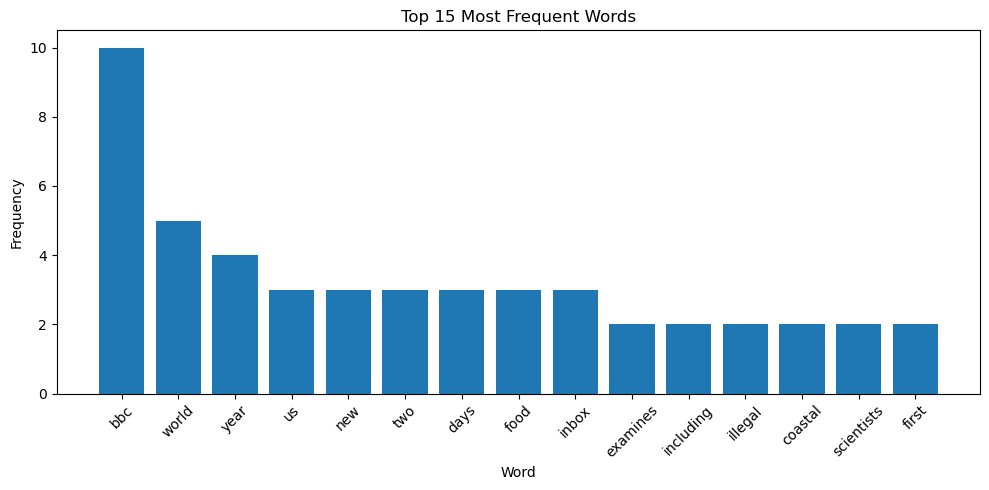

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_words["Word"],
    top_words["Frequency"]
)

plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 8. Lexical Diversity

Lexical diversity measures vocabulary richness.

The formula is:

$ \text{Lexical Diversity} = \frac{\text{Unique Words}}{\text{Total Words}} $

In [8]:
lexical_diversity = len(set(clean_tokens)) / len(clean_tokens)

print("Lexical Diversity:", lexical_diversity)

Lexical Diversity: 0.8825757575757576


### Interpretation

* Values closer to **1** indicate greater vocabulary variation.
* Lower values suggest greater repetition.

A lexical diversity score of 0.88 indicates a highly varied vocabulary with relatively little word repetition. This is expected for the BBC homepage, as it contains headlines and summaries from many different news categories, introducing a wide range of topic-specific words. The high score reflects the linguistic richness and broad subject coverage of the website.

---

## 9. Part-of-Speech Tagging

Part-of-speech (POS) tagging assigns grammatical categories to words.

Examples include:

| Tag | Meaning   |
| --- | --------- |
| NN  | Noun      |
| VB  | Verb      |
| JJ  | Adjective |
| RB  | Adverb    |

---

In [9]:
tagged_words = pos_tag(clean_tokens)

tagged_words[:20]

[('public', 'JJ'),
 ('spending', 'NN'),
 ('watchdog', 'NN'),
 ('examines', 'VBZ'),
 ('property', 'NN'),
 ('arrangements', 'NNS'),
 ('royals', 'NNS'),
 ('including', 'VBG'),
 ('andrew', 'JJ'),
 ('ukraine', 'JJ'),
 ('says', 'VBZ'),
 ('struck', 'JJ'),
 ('five', 'CD'),
 ('ships', 'NNS'),
 ('carrying', 'VBG'),
 ('illegal', 'JJ'),
 ('cargo', 'NNS'),
 ('sea', 'NN'),
 ('azov', 'IN'),
 ('coastal', 'JJ')]

## 10. Distribution of Grammatical Categories

---

In [10]:
pos_counts = {}

for word, tag in tagged_words:
    pos_counts[tag] = pos_counts.get(tag, 0) + 1

pos_df = pd.DataFrame(
    pos_counts.items(),
    columns=["POS", "Count"]
)

pos_df = pos_df.sort_values(
    by="Count",
    ascending=False
)

pos_df.head(10)

,POS,Count
1,NN,174
0,JJ,103
3,NNS,82
7,VBP,32
4,VBG,29
10,VBD,28
8,VBN,17
13,RB,15
2,VBZ,14
6,IN,9


## 11. Visualizing POS Tags

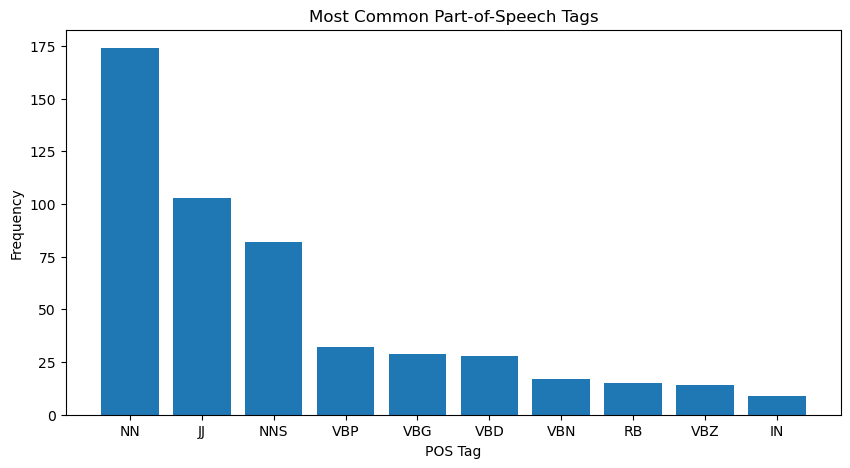

In [11]:
top_pos = pos_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_pos["POS"],
    top_pos["Count"]
)

plt.title("Most Common Part-of-Speech Tags")
plt.xlabel("POS Tag")
plt.ylabel("Frequency")

plt.show()

### Linguistic Interpretation

The POS distribution is dominated by nouns `(NN, NNS)` and adjectives `(JJ)`, indicating that the BBC homepage primarily focuses on presenting people, places, events, and descriptive information. The presence of various verb forms `(VBP, VBD, VBG, VBN, VBZ)` reflects ongoing and completed actions reported in the news, while adverbs `(RB)` and numbers `(CD)` appear less frequently. Overall, the results are consistent with the informative and descriptive style of news headlines and article summaries.

---

## 12. Investigating Word Length

Another interesting feature is word length distribution.

### Discussion

Word length often reflects text complexity.

Academic writing generally contains longer words, while conversational texts tend to rely on shorter vocabulary.

---

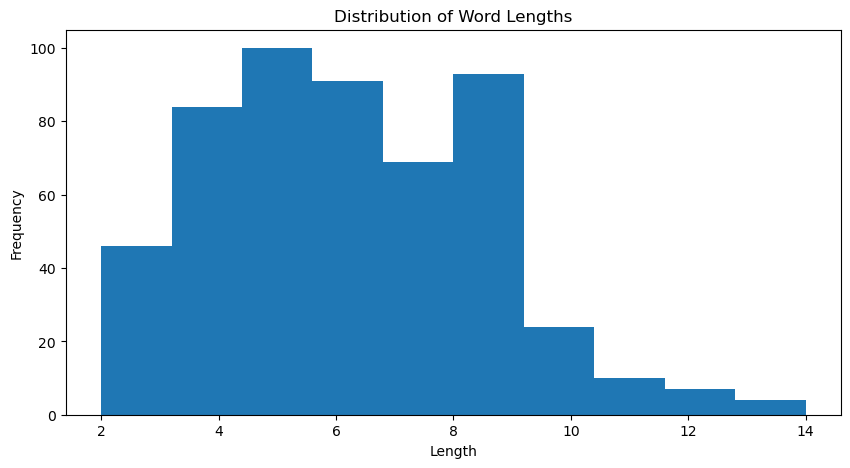

In [12]:
word_lengths = [len(word) for word in clean_tokens]

plt.figure(figsize=(10,5))

plt.hist(word_lengths)

plt.title("Distribution of Word Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## 13. Bigram Analysis

Single words do not capture all linguistic patterns. We can also examine common two-word combinations, known as bigrams.

In [13]:
from nltk.util import bigrams

bigram_list = list(bigrams(clean_tokens))

bigram_freq = FreqDist(bigram_list)

bigram_freq.most_common(10)

[(('follow', 'live'), 2),
 (('public', 'spending'), 1),
 (('spending', 'watchdog'), 1),
 (('watchdog', 'examines'), 1),
 (('examines', 'property'), 1),
 (('property', 'arrangements'), 1),
 (('arrangements', 'royals'), 1),
 (('royals', 'including'), 1),
 (('including', 'andrew'), 1),
 (('andrew', 'ukraine'), 1)]

Due to the page's high lexical diversity, only three bigrams appear more than once. This is not particularly surprising, as the BBC homepage brings together a wide range of topics, from politics and business to culture, science and sport. As a result, the highly varied vocabulary leaves little room for repeated word pairings.

---


## 14. Reflection

This project demonstrates how relatively simple NLP techniques can uncover meaningful linguistic patterns in real-world web content.

The analysis revealed:

* A diverse vocabulary reflecting the wide range of topics covered on the BBC homepage.
* A high lexical diversity score (0.88), indicating limited word repetition and substantial linguistic variety.
* A grammatical structure dominated by nouns and adjectives, consistent with the informative and descriptive nature of news headlines and summaries.
* Common word combinations that highlight recurring themes and topics across the website.

Although these methods are relatively basic, they provide valuable insights into the characteristics of online news language and form the foundation of more advanced NLP applications such as sentiment analysis, topic modeling, machine translation, and large language models.

---

# Conclusion

Computational linguistics bridges the gap between language and data science. By combining Beautiful Soup with NLTK, it is possible to transform an ordinary web page into a structured linguistic dataset and explore its properties quantitatively.

This notebook demonstrates that even a modest amount of Python code can produce valuable linguistic insights. Future work could include sentiment analysis, named entity recognition, topic modeling, or comparisons between multiple genres of text.

---

## References

* NLTK Documentation: https://www.nltk.org/
* Beautiful Soup Documentation: https://www.crummy.com/software/BeautifulSoup/
* Python Documentation: https://docs.python.org/